In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [13]:
data = pd.read_csv("C://Users//utsav//OneDrive//Desktop//student_placement_career_success_dataset_2026.csv")

In [14]:
data.head()

,Age,Gender,College_Tier,Specialization,CGPA,DSA_Problems_Solved,Internships,Certifications,Projects_Count,Communication_Skills,Aptitude_Test_Score,LeetCode_Rating,GitHub_Contributions,Hackathons_Participated,AI_ML_Skill_Level,System_Design_Knowledge,Resume_Score,Mock_Interview_Score,Placement_Status,Salary_LPA
0,19,Male,Tier 3,AI/ML,7.70,229,0,1,11,87,46,1676,241,6,1,1,50,62,1,9.99
1,21,Other,Tier 3,Civil,6.97,486,0,10,12,74,88,1718,82,3,8,10,62,35,1,13.06
2,20,Other,Tier 2,Electronics,6.74,180,0,5,2,45,83,1534,0,1,6,6,83,68,1,7.74
3,18,Other,Tier 2,Computer Science,6.64,98,4,6,2,75,72,1559,47,5,10,4,90,43,1,12.29
4,18,Other,Tier 2,Electronics,8.67,216,4,3,2,64,70,1473,6,7,6,3,68,80,1,14.45


In [15]:
data.tail()

,Age,Gender,College_Tier,Specialization,CGPA,DSA_Problems_Solved,Internships,Certifications,Projects_Count,Communication_Skills,Aptitude_Test_Score,LeetCode_Rating,GitHub_Contributions,Hackathons_Participated,AI_ML_Skill_Level,System_Design_Knowledge,Resume_Score,Mock_Interview_Score,Placement_Status,Salary_LPA
19995,19,Female,Tier 3,Data Science,7.55,0,0,2,1,87,82,1608,14,0,4,3,73,62,1,13.30
19996,22,Male,Tier 3,AI/ML,8.13,116,3,9,8,68,82,1260,230,7,2,7,94,53,1,15.89
19997,25,Other,Tier 1,Electronics,7.64,172,0,3,4,74,77,810,179,6,5,8,74,45,1,10.43
19998,18,Female,Tier 2,Data Science,7.84,373,1,8,2,54,76,1375,137,7,1,3,90,60,1,13.90
19999,20,Male,Tier 1,AI/ML,6.97,164,1,4,12,91,74,1593,103,0,9,10,65,49,1,13.22


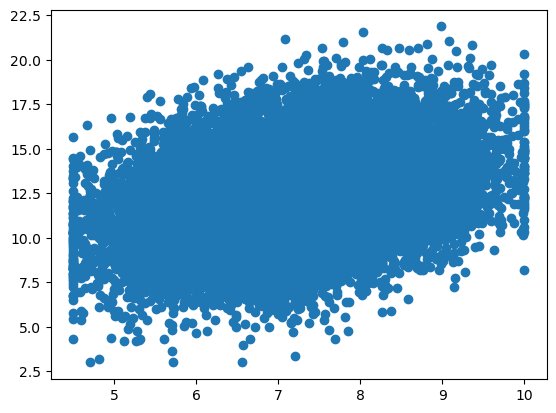

In [16]:
x1 = data['CGPA']
y1 = data['Salary_LPA']
plt.scatter(x1 , y1)

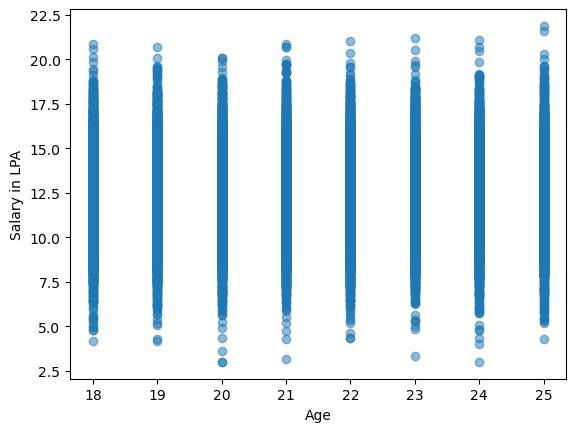

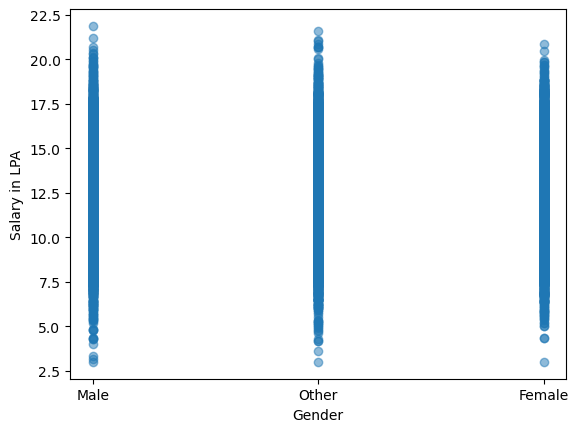

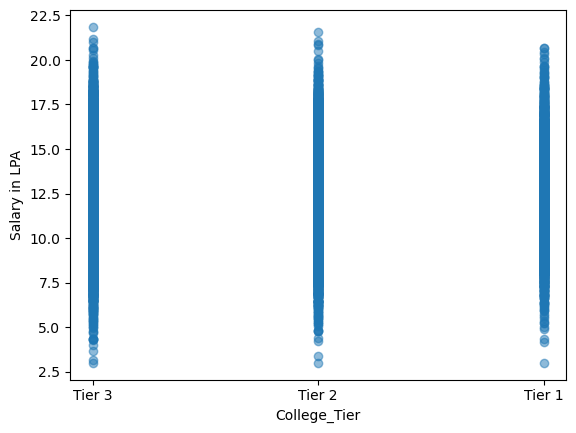

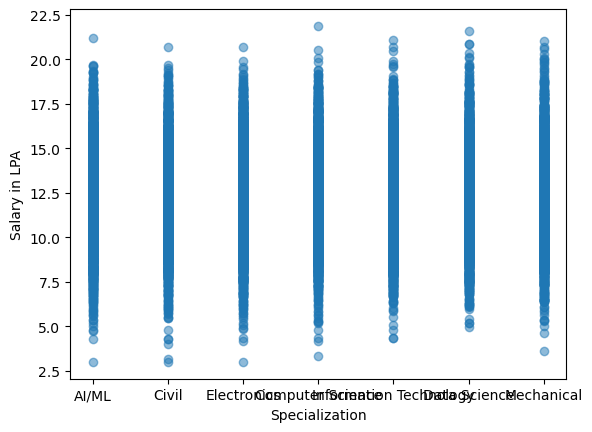

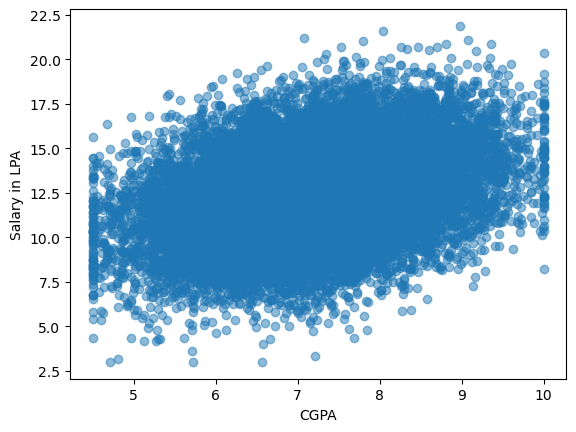

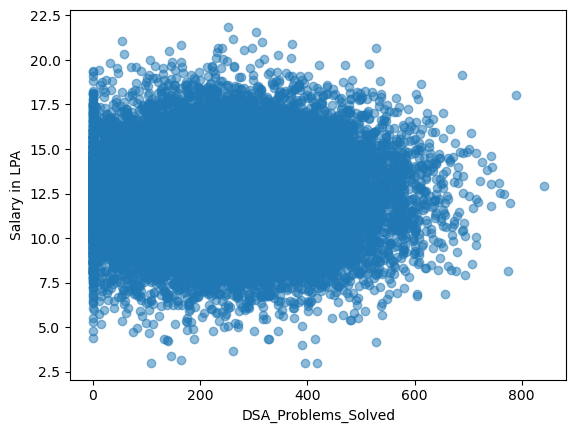

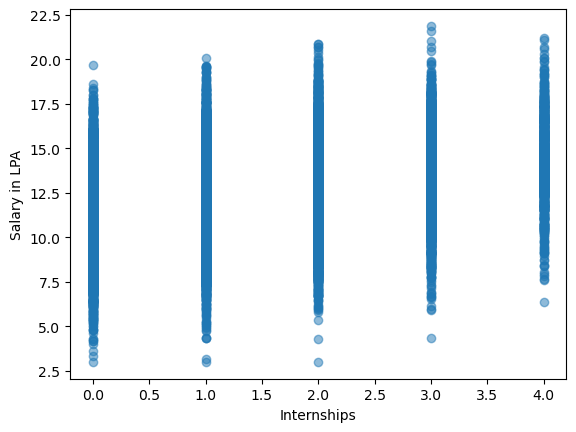

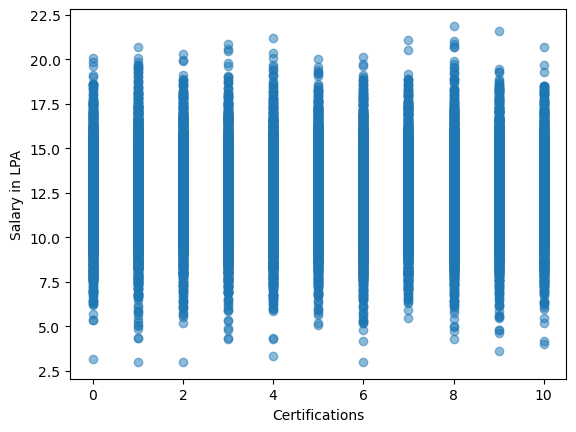

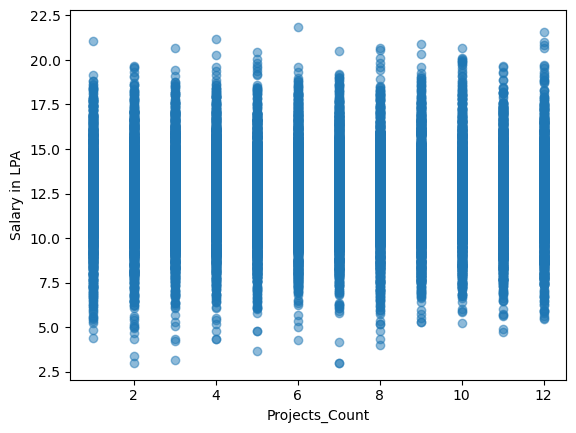

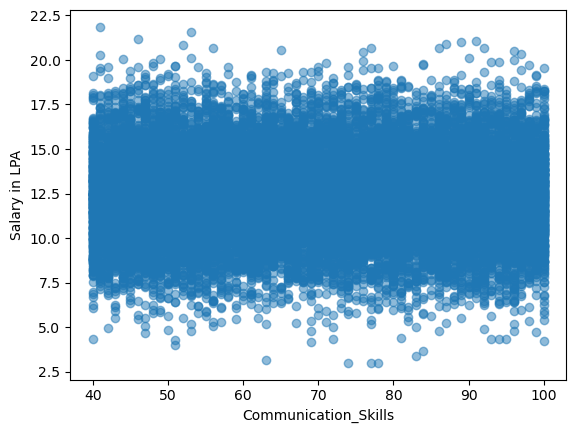

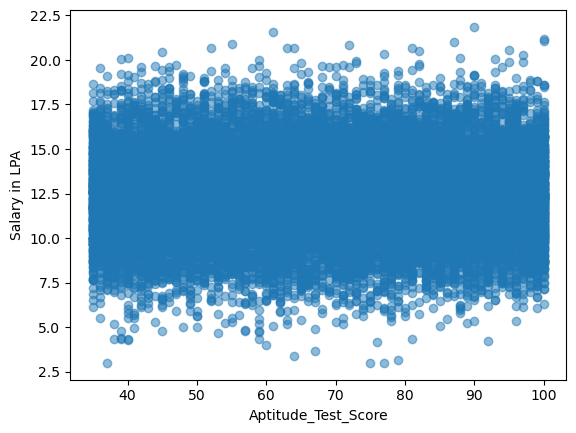

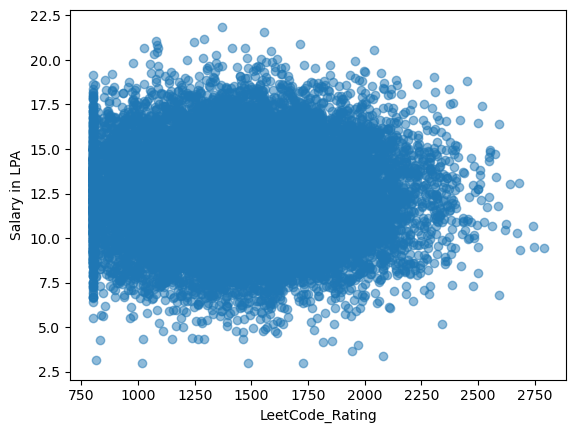

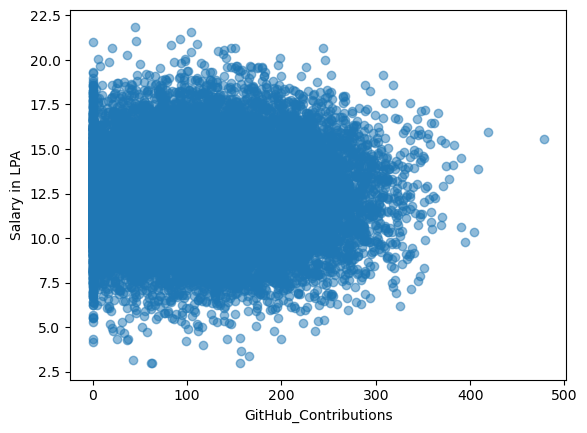

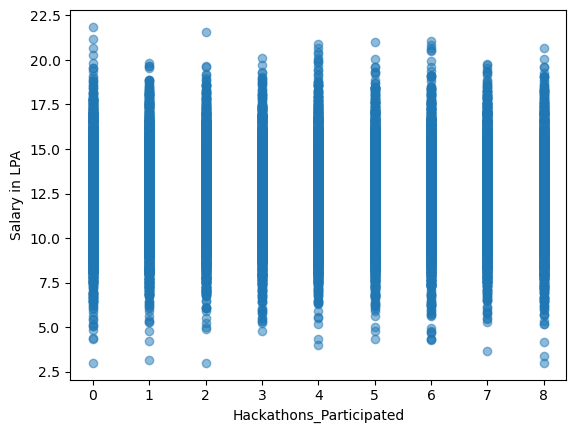

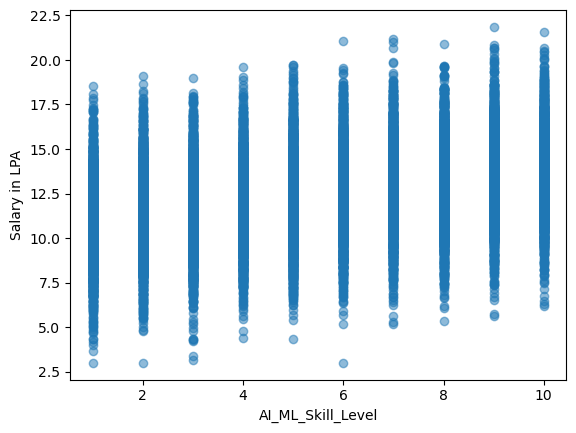

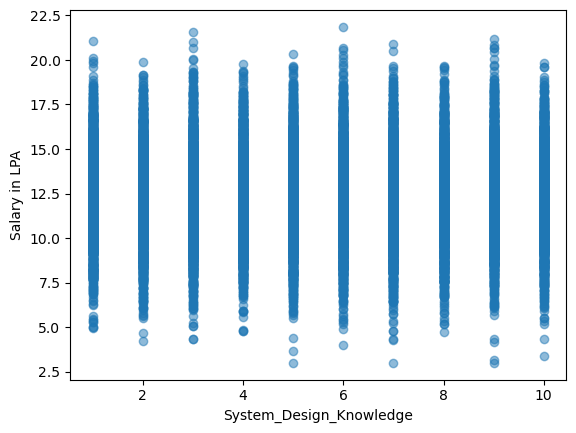

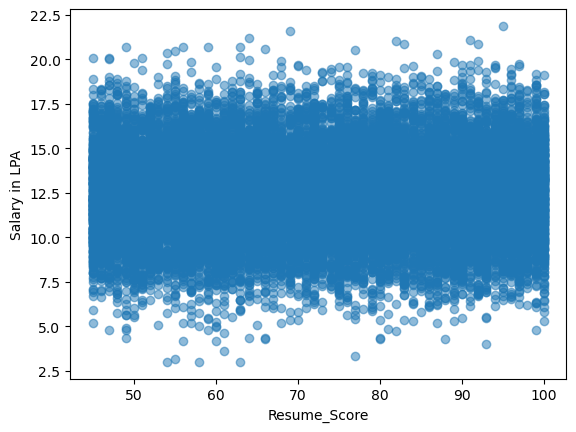

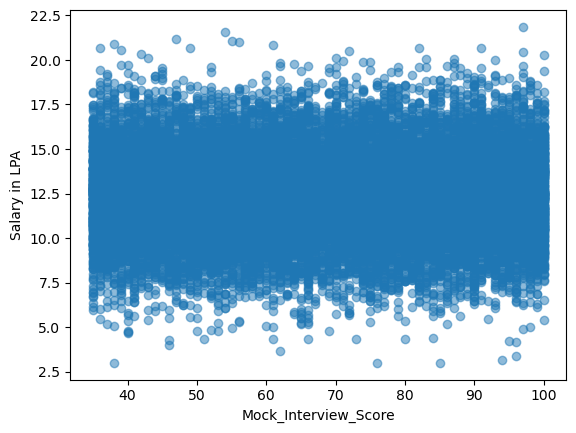

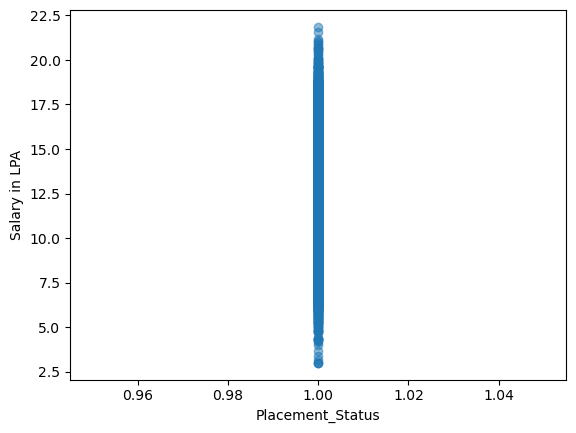

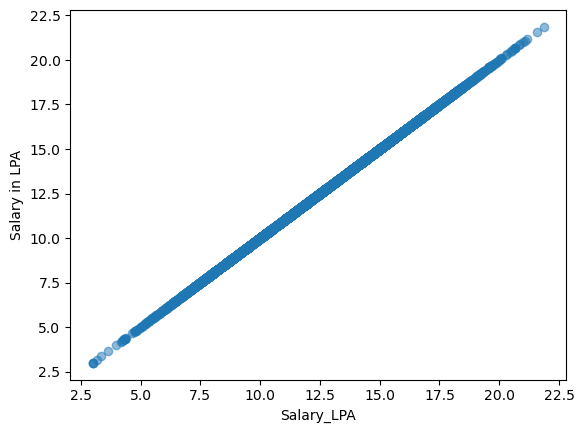

In [22]:
for column in data.columns:
    xn = data[column]
    yn = data['Salary_LPA']
    plt.scatter(xn , yn , alpha = 0.5)
    plt.xlabel(column)
    plt.ylabel('Salary in LPA')
    plt.show()
    

In [44]:
x1 = data[['DSA_Problems_Solved']]
y1 = data[['Salary_LPA']]

In [45]:
from sklearn.model_selection import train_test_split

In [46]:
x_train , x_test , y_train , y_test = train_test_split(x1 , y1 , test_size = 0.25 , random_state = 42)

In [47]:
x_train.shape

(15000, 1)

In [48]:
x_test.shape

(5000, 1)

In [49]:
y_train.shape

(15000, 1)

In [50]:
y_test.shape

(5000, 1)

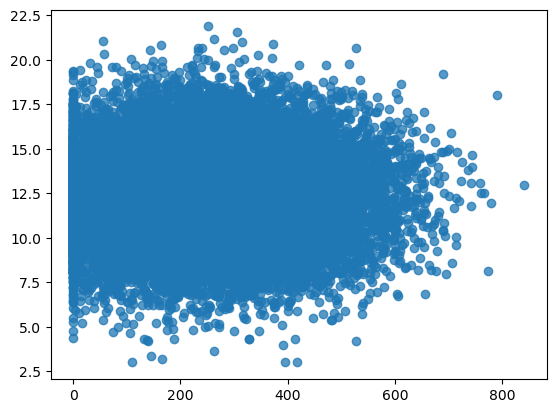

In [51]:
plt.scatter(x1 , y1 , alpha = 0.75)

In [52]:
from sklearn.linear_model import LogisticRegression

In [53]:
from sklearn.linear_model import Lasso , Ridge

In [54]:
x_train , y_train

(       DSA_Problems_Solved
 5514                   475
 1266                    46
 5864                   466
 15865                  302
 12892                  368
 ...                    ...
 11284                    0
 11964                  419
 5390                   123
 860                     45
 15795                  254
 
 [15000 rows x 1 columns],
        Salary_LPA
 5514        11.21
 1266        15.09
 5864        10.60
 15865       10.31
 12892       12.06
 ...           ...
 11284       10.37
 11964       12.01
 5390        11.02
 860         10.21
 15795       12.56
 
 [15000 rows x 1 columns])

In [60]:
from sklearn.metrics import r2_score, mean_absolute_error , mean_squared_error , accuracy_score

In [65]:
alphas = np.linspace(0.5, 10, 20) 
results = {}
for alpha in alphas:
    model = Ridge(alpha=alpha)
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    results[alpha] = r2_score(y_test, y_pred)
for alpha, score in results.items():
    print(f"Alpha: {alpha}  →  R²: {score}")

best_alpha = max(results, key=results.get)
print(f"\nBest alpha: {best_alpha:.2f}  →  R²: {results[best_alpha]:.4f}")

Alpha: 0.50  →  R²: -0.0011
Alpha: 1.00  →  R²: -0.0011
Alpha: 1.50  →  R²: -0.0011
Alpha: 2.00  →  R²: -0.0011
Alpha: 2.50  →  R²: -0.0011
Alpha: 3.00  →  R²: -0.0011
Alpha: 3.50  →  R²: -0.0011
Alpha: 4.00  →  R²: -0.0011
Alpha: 4.50  →  R²: -0.0011
Alpha: 5.00  →  R²: -0.0011
Alpha: 5.50  →  R²: -0.0011
Alpha: 6.00  →  R²: -0.0011
Alpha: 6.50  →  R²: -0.0011
Alpha: 7.00  →  R²: -0.0011
Alpha: 7.50  →  R²: -0.0011
Alpha: 8.00  →  R²: -0.0011
Alpha: 8.50  →  R²: -0.0011
Alpha: 9.00  →  R²: -0.0011
Alpha: 9.50  →  R²: -0.0011
Alpha: 10.00  →  R²: -0.0011

Best alpha: 10.00  →  R²: -0.0011


In [70]:
dsa_questions_solved = int(input("What are the number of DSA questions you solved? "))
print(f"The predicted salary that you might get by solving {dsa_questions_solved} is : ")
expected_salary = model.predict([[dsa_questions_solved]])
print(f"{expected_salary} LPA")

What are the number of DSA questions you solved?  414


The predicted salary that you might get by solving 414 is : 
[12.44815067] LPA


C:\Users\utsav\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(


In [71]:
from sklearn.linear_model import LinearRegression

In [85]:
X = data[['CGPA']]
Y = data['Salary_LPA']
x_train_1 , x_test_1 , y_train_1 , y_test_1 = train_test_split(X , Y , test_size = 0.25 , random_state = 42)
linear_model = LinearRegression()

In [89]:
linear_model.fit(x_train_1 , y_train_1)
y_predicted_1 = linear_model.predict(x_test_1)

In [90]:
linear_model.coef_

array([0.80506699])

<Axes: xlabel='CGPA', ylabel='Salary_LPA'>

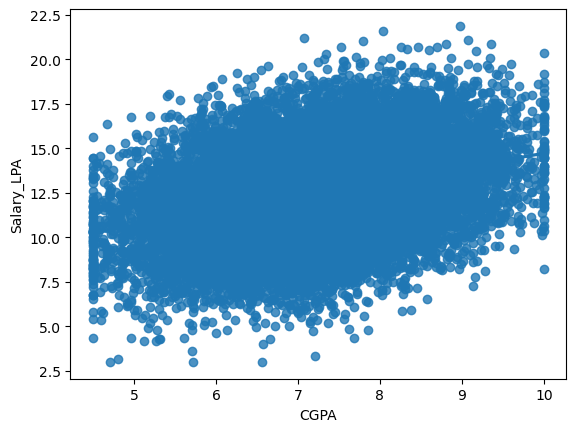

In [91]:
sns.regplot(x = X,y = Y)

In [92]:
r2_score(y_test_1 , y_predicted_1)

0.11460316240848945

In [93]:
mean_absolute_error(y_test_1 , y_predicted_1)

1.867234983533532

In [97]:
data.describe()

,Age,CGPA,DSA_Problems_Solved,Internships,Certifications,Projects_Count,Communication_Skills,Aptitude_Test_Score,LeetCode_Rating,GitHub_Contributions,Hackathons_Participated,AI_ML_Skill_Level,System_Design_Knowledge,Resume_Score,Mock_Interview_Score,Placement_Status,Salary_LPA
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000,20000.00000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.0,20000.000000
mean,21.506600,7.202949,253.263700,1.450200,5.01255,6.503900,70.15475,67.488250,1452.676650,121.607400,3.993200,5.498350,5.490400,72.318750,67.479050,1.0,12.433874
std,2.295347,1.005041,144.140893,1.160296,3.14957,3.437932,17.70118,18.995447,340.902149,74.906931,2.586559,2.867195,2.856522,16.267538,19.031673,0.0,2.468236
min,18.000000,4.500000,0.000000,0.000000,0.00000,1.000000,40.00000,35.000000,800.000000,0.000000,0.000000,1.000000,1.000000,45.000000,35.000000,1.0,3.000000
25%,19.000000,6.520000,150.000000,0.000000,2.00000,3.000000,55.00000,51.000000,1210.000000,65.000000,2.000000,3.000000,3.000000,58.000000,51.000000,1.0,10.760000
50%,22.000000,7.210000,249.500000,1.000000,5.00000,7.000000,70.00000,67.000000,1447.000000,120.000000,4.000000,6.000000,5.000000,72.000000,67.000000,1.0,12.430000
75%,24.000000,7.880000,352.000000,2.000000,8.00000,9.000000,86.00000,84.000000,1684.000000,173.000000,6.000000,8.000000,8.000000,87.000000,84.000000,1.0,14.080000
max,25.000000,10.000000,841.000000,4.000000,10.00000,12.000000,100.00000,100.000000,2790.000000,478.000000,8.000000,10.000000,10.000000,100.000000,100.000000,1.0,21.860000


In [99]:
from sklearn.model_selection import GridSearchCV

In [101]:
alpha = np.linspace(0.5 , 20 , 40)
model = Ridge()
param_grid = {"alpha" : alpha}
grid_model = GridSearchCV(model , param_grid = param_grid , cv = 5)
grid_model.fit(x_train_1 , y_train_1)
y_test_1_lr = grid_model.predict(x_test_1)

In [102]:
grid_model

GridSearchCV(cv=5, estimator=Ridge(),
             param_grid={'alpha': array([ 0.5,  1. ,  1.5,  2. ,  2.5,  3. ,  3.5,  4. ,  4.5,  5. ,  5.5,
        6. ,  6.5,  7. ,  7.5,  8. ,  8.5,  9. ,  9.5, 10. , 10.5, 11. ,
       11.5, 12. , 12.5, 13. , 13.5, 14. , 14.5, 15. , 15.5, 16. , 16.5,
       17. , 17.5, 18. , 18.5, 19. , 19.5, 20. ])})

In [104]:
mean_absolute_error(y_test , y_test_1_lr)

1.8672352855677277

In [105]:
mean_squared_error(y_test , y_test_1_lr)

5.449649795452185